## Shuffled vs. I.I.D. Draws from Discrete Distributions

When simulating heterogeneous-agent models, income shocks are drawn from a discrete approximation to the true shock distribution.  The standard approach draws each agent's shock independently (i.i.d.), so the empirical frequency of each outcome in a finite sample deviates from the target probabilities by sampling noise of order $O(1/\sqrt{N})$.

HARK's `DiscreteDistribution.draw(replicates=k)` offers an alternative: **shuffled draws** that match the target probabilities exactly by allocating $k$ copies of the minimal full-coverage sample, then randomly permuting the assignment across agents.  This eliminates sampling noise from the cross-sectional distribution of shocks in any single period.

This notebook demonstrates the difference and measures the gain.

**Related:**
- [PR #1691](https://github.com/econ-ark/HARK/pull/1691) — merged the `shuffle` parameter into HARK
- [PR #1244](https://github.com/econ-ark/HARK/pull/1244) — original (unmerged) reshuffling proposal
- [Harmenberg (2021)](https://doi.org/10.1016/j.jedc.2021.104185) — permanent-income-neutral measure (a complementary variance-reduction technique)

`# Set up the computational environment: (in JupyterLab, click the dots)`

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from HARK.distributions import DiscreteDistribution

# The key constraint: perfect $N$

Shuffle should only be used when the population size $N$ is an **exact multiple** of the minimum sample size.  For an equiprobable distribution with $J$ outcomes, that minimum is $J$ itself, so $N$ must be a multiple of $J$.  (More generally, if outcomes have probabilities $p_j = n_j / D$ in lowest terms, the minimum is $\text{lcm}$ of the denominators.)

At perfect $N$, shuffle assigns **exactly** $N/J$ agents to each outcome — zero leftover slots, zero sampling noise in the marginal frequencies.  This is a hard guarantee, not an approximation.

### Why this works: expectations are cross-sectional averages

As discussed in [Carroll (2024), *Solving Microeconomic Dynamic Stochastic Optimization Problems*](https://llorracc.github.io/SolvingMicroDSOPs) (Sections 6.2 and 10), the formula for computing an expectation over an equiprobable discrete approximation,

$$\mathbb{E}[g(\theta)] \approx \frac{1}{J}\sum_{j=1}^{J} g(\theta_j),$$

is **structurally identical** to the cross-sectional average of $J$ simulated agents each assigned one of the $J$ shock values.  When we simulate $N = k \cdot J$ agents using the shuffled draw — which assigns exactly $k$ agents to each $\theta_j$ — the cross-sectional average reproduces the expectation formula exactly:

$$\frac{1}{N}\sum_{i=1}^{N} g(\theta_i) = \frac{1}{J}\sum_{j=1}^{J} g(\theta_j).$$

This is why the shuffled-draw simulation has no sampling noise in the cross-sectional mean of any function of the shocks: the simulation **is** the expectation formula, replicated $k$ times.  

One useful implication of this point is that the use of this method of simulation eliminates a common category of bug, in which there is some subtle but numerically significant difference between the expectations calculated using the solution algorithm and the results of the simulation.  Such a bug is impossible when the formulae for expectations and simulation are identical.

### The `replicates` parameter

The `replicates` parameter handles the bookkeeping: `F.draw(replicates=k)` computes the minimal full-coverage size automatically, multiplies by $k$, and forces shuffled draws.  It warns if `1/p_j` is not an integer for some outcome.

To see the difference concretely, we draw $k = 5$ replicates (giving $N = 5 \times 4 = 20$) from a $J = 4$ equiprobable distribution using both methods.

# Minimum sample size $J_{\min}$ for general distributions

For an equiprobable distribution with $J$ outcomes, the minimum sample size is simply $J$.  For a general probability vector $(p_1, \ldots, p_J)$, we need the smallest positive integer $N$ such that $N \cdot p_j$ is a positive integer for every atom $j$.

**Computation.**  Express each $p_j$ as a fraction $n_j / d_j$ in lowest terms.  Then

$$J_{\min} = \operatorname{lcm}(d_1, \ldots, d_J).$$

### Product-of-conditional-inverses interpretation

When a distribution is a joint over independent shock dimensions, $J_{\min}$ factors as the **product** of the inverse conditional probabilities at each level of the hierarchy.

*Example:* Suppose the unemployment probability is $p_u = 0.05 = 1/20$, and conditional on employment there are $3$ equiprobable permanent shocks and $3$ equiprobable transitory shocks.  The joint distribution has $1 + 3 \times 3 = 10$ atoms:

| Atom | Probability | As fraction |
|------|------------|-------------|
| Unemployed | $0.05$ | $1/20$ |
| Each of 9 employed states | $0.95/9$ | $19/180$ |

The denominators are $20$ and $180$, so $J_{\min} = \operatorname{lcm}(20, 180) = 180$.  This equals the product of conditional inverses:

$$J_{\min} = \underbrace{20}_{1/p_u} \times \underbrace{3}_{1/p_{\text{perm}|\text{emp}}} \times \underbrace{3}_{1/p_{\text{tran}|\text{emp}}} = 180.$$

With $N = 180$: exactly $9$ unemployed agents, $171$ employed agents, and each of the $9$ (perm, tran) combinations is assigned to exactly $171/9 = 19$ employed agents.

### Validation criterion

For shuffled draws to be practical, $J_{\min}$ must not be too large.  A large $J_{\min}$ means at least one shock dimension has a very fine conditional probability, requiring an impractically large population even for $k = 1$ replicate.

**Rule:** if $J_{\min} > 10{,}000$, the `replicates` parameter raises an error.  This corresponds roughly to saying that no conditional shock probability should be smaller than $0.01\%$ (i.e., no conditional inverse exceeds $10{,}000$).  In practice, standard HARK shock approximations (typically 3–11 equiprobable points) produce $J_{\min}$ well under this bound.

If $J_{\min}$ is unexpectedly large, this usually signals that the distribution was not constructed from clean rational probabilities — for instance, if the shock approximation used quadrature weights that are irrational.  The remedy is to use equiprobable discretizations, which always give $J_{\min} = J$.

In [2]:
# Equiprobable J=4 distribution (same one used throughout the notebook)
J_demo = 4
P_demo = np.ones(J_demo) / J_demo
log_psi_spread_demo = 0.1
log_vals_demo = np.linspace(-log_psi_spread_demo, log_psi_spread_demo, J_demo)
X_demo = np.exp(log_vals_demo)
X_demo = X_demo / np.mean(X_demo)  # E[psi] = 1
F_demo = DiscreteDistribution(P_demo, X_demo, seed=0)

k_demo = 5  # replicates
N_demo = k_demo * J_demo  # = 20

print(f"J = {J_demo} equiprobable outcomes")
print(f"Outcomes (psi values): {X_demo.round(6)}")
print(f"replicates = {k_demo}  →  N = {k_demo} × {J_demo} = {N_demo}")


def empirical_freq(draws, atoms):
    """Compute empirical frequency of each atom in the draws."""
    freq = np.array([np.sum(np.isclose(draws, a)) for a in atoms])
    return freq / len(draws)

J = 4 equiprobable outcomes
Outcomes (psi values): [0.902329 0.964535 1.031029 1.102107]
replicates = 5  →  N = 5 × 4 = 20


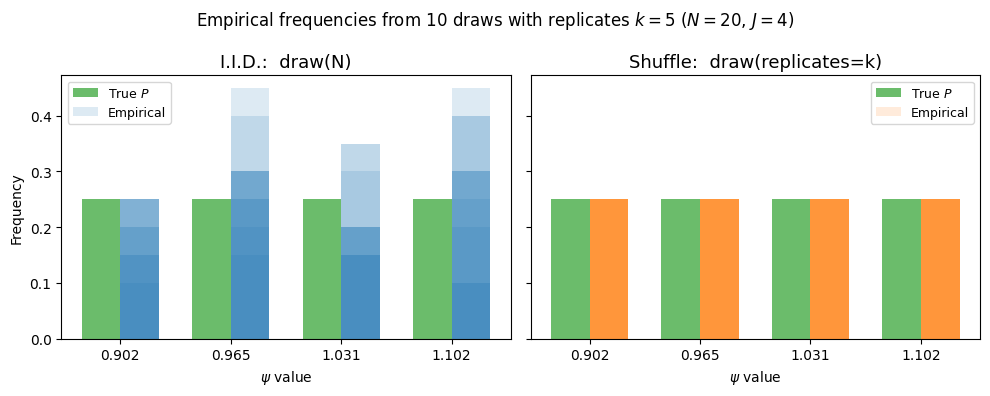

With draw(replicates=k), every repetition gives exactly 1/J per outcome.


In [3]:
# Compare i.i.d. draw(N) vs shuffled draw(replicates=k), 10 repetitions
n_reps = 10
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bar_width = 0.35
x_pos = np.arange(J_demo)

for ax, use_replicates, title in [
    (axes[0], False, "I.I.D.:  draw(N)"),
    (axes[1], True, "Shuffle:  draw(replicates=k)"),
]:
    ax.bar(
        x_pos - bar_width / 2,
        P_demo,
        bar_width,
        label="True $P$",
        alpha=0.7,
        color="C2",
    )
    for r in range(n_reps):
        F_r = DiscreteDistribution(P_demo, X_demo, seed=r)
        if use_replicates:
            draws = F_r.draw(replicates=k_demo)
        else:
            draws = F_r.draw(N_demo)
        freq = empirical_freq(draws, X_demo)
        ax.bar(
            x_pos + bar_width / 2,
            freq,
            bar_width,
            alpha=0.15,
            color="C0" if not use_replicates else "C1",
            label="Empirical" if r == 0 else None,
        )
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{v:.3f}" for v in X_demo])
    ax.set_xlabel(r"$\psi$ value")
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Frequency")
fig.suptitle(
    f"Empirical frequencies from {n_reps} draws with replicates $k = {k_demo}$ ($N = {N_demo}$, $J = {J_demo}$)",
    fontsize=12,
)
fig.tight_layout()
plt.show()
print("With draw(replicates=k), every repetition gives exactly 1/J per outcome.")

# Time-series variance of the cross-sectional mean

In a simulation with $N$ agents, the cross-sectional mean of $\mathbf{p}$ (or $\log\mathbf{p}$) fluctuates from period to period.  The **time-series variance** of this mean quantifies how noisy the simulation's aggregate dynamics are.

After an initial transient, $\bar{\ell}_n = \frac{1}{N}\sum_i \log\mathbf{p}_{i,n}$ follows an approximate AR(1):

$$\bar{\ell}_{n+1} \approx (1-d)\,\bar{\ell}_n + \mu + \eta_n$$

where $\eta_n$ has two independent components:
- **Death noise:** agents who die (and get replaced at $\log\mathbf{p} = 0$) perturb the mean.  Variance $\approx \frac{d(1-d)}{N}\bigl(V_\infty + E_\infty^2\bigr)$, where $V_\infty, E_\infty$ are the ergodic cross-sectional variance and mean of $\log\mathbf{p}$.
- **Shock noise:** the empirical mean of $\log\psi$ deviates from $\mu$.  With i.i.d. draws, variance $= \sigma^2/N$.  With **shuffle at perfect $N$**, this is **exactly zero**.

### Analytical formula

The ergodic time-series variance of an AR(1) with coefficient $\rho = 1-d$ and innovation variance $v$ is $v/(1-\rho^2)$.  So:

$$\text{Var}_{\text{ts}}^{\text{shf}} = \frac{(1-d)(V_\infty + E_\infty^2)}{N(2-d)}, \qquad
\text{Var}_{\text{ts}}^{\text{iid}} = \text{Var}_{\text{ts}}^{\text{shf}} + \frac{\sigma^2}{N\,d(2-d)}$$

Both scale as $1/N$, so the **variance-reduction ratio is constant** in $N$:

$$R = \frac{\text{Var}_{\text{ts}}^{\text{iid}}}{\text{Var}_{\text{ts}}^{\text{shf}}} = 1 + \frac{\sigma^2}{d(1-d)(V_\infty + E_\infty^2)}$$

In [4]:
# --- Parameters ---
J = 4  # equiprobable permanent shock outcomes
death_prob = 0.02
T = 500  # total periods
burn = 100  # discard first 100 periods

# Sweep over replicates: N = k * J
replicates = [1, 2, 5, 10, 25, 50, 100, 250]

# Equiprobable permanent shock distribution, E[psi] = 1
log_psi_spread = 0.1
log_psi_vals = np.linspace(-log_psi_spread, log_psi_spread, J)
psi_vals = np.exp(log_psi_vals)
psi_vals = psi_vals / np.mean(psi_vals)
P_equi = np.ones(J) / J

mu = np.mean(np.log(psi_vals))
sigma2 = np.var(np.log(psi_vals))
d = death_prob

# Ergodic cross-sectional moments
V_erg = (1 - d) / d * sigma2 + (1 - d) / d**2 * mu**2  # Var(log p)
E_erg = (1 - d) * mu / d  # E[log p]


# Theoretical time-series variances (functions of N)
def theory_ts_var_shf(N):
    return (1 - d) * (V_erg + E_erg**2) / (N * (2 - d))


def theory_ts_var_iid(N):
    return theory_ts_var_shf(N) + sigma2 / (N * d * (2 - d))


R_theory = 1 + sigma2 / (d * (1 - d) * (V_erg + E_erg**2))

print(f"J = {J},  d = {death_prob},  T = {T},  burn-in = {burn}")
print(f"mu = {mu:.6f},  sigma^2 = {sigma2:.6f}")
print(f"Ergodic V_inf = {V_erg:.6f},  E_inf = {E_erg:.6f}")
print(f"V_inf + E_inf^2 = {V_erg + E_erg**2:.6f}")
print(f"\nTheoretical variance-reduction ratio R = {R_theory:.3f}")
print(f"Replicates k: {replicates}  →  N: {[k * J for k in replicates]}")

J = 4,  d = 0.02,  T = 500,  burn-in = 100
mu = -0.002776,  sigma^2 = 0.005556
Ergodic V_inf = 0.291103,  E_inf = -0.136026
V_inf + E_inf^2 = 0.309606

Theoretical variance-reduction ratio R = 1.916
Replicates k: [1, 2, 5, 10, 25, 50, 100, 250]  →  N: [4, 8, 20, 40, 100, 200, 400, 1000]


`# Run simulations for each N, compute time-series variance of mean(pLvl) and mean(log pLvl):`

In [5]:
import time


def simulate_one(k, J, T, psi_vals, P_equi, death_prob, seed, shuffle):
    """Run one simulation, return time series of mean(pLvl) and mean(log pLvl).

    k : int — number of replicates (N = k * J)
    """
    N = k * J
    rng = np.random.default_rng(seed)
    F = DiscreteDistribution(P_equi, psi_vals, seed=seed + 1000)

    log_pLvl = np.zeros(N)
    mean_log = np.zeros(T)
    mean_lvl = np.zeros(T)

    for t in range(T):
        dies = rng.random(N) < death_prob
        log_pLvl[dies] = 0.0
        if shuffle:
            psi_draws = F.draw(replicates=k)
        else:
            psi_draws = F.draw(N)
        log_pLvl += np.log(psi_draws)
        mean_log[t] = np.mean(log_pLvl)
        mean_lvl[t] = np.mean(np.exp(log_pLvl))

    return mean_log, mean_lvl


# Average time-series variance over several seeds for robustness
n_seeds = 10

ts_var_log_iid = np.zeros(len(replicates))
ts_var_log_shf = np.zeros(len(replicates))
ts_var_lvl_iid = np.zeros(len(replicates))
ts_var_lvl_shf = np.zeros(len(replicates))
time_iid = np.zeros(len(replicates))
time_shf = np.zeros(len(replicates))

for ri, k in enumerate(replicates):
    N = k * J
    vlog_iid, vlog_shf, vlvl_iid, vlvl_shf = [], [], [], []

    t0 = time.perf_counter()
    for s in range(n_seeds):
        ml_i, mp_i = simulate_one(
            k, J, T, psi_vals, P_equi, death_prob, seed=s, shuffle=False
        )
        vlog_iid.append(np.var(ml_i[burn:]))
        vlvl_iid.append(np.var(mp_i[burn:]))
    time_iid[ri] = time.perf_counter() - t0

    t0 = time.perf_counter()
    for s in range(n_seeds):
        ml_s, mp_s = simulate_one(
            k, J, T, psi_vals, P_equi, death_prob, seed=s + 500, shuffle=True
        )
        vlog_shf.append(np.var(ml_s[burn:]))
        vlvl_shf.append(np.var(mp_s[burn:]))
    time_shf[ri] = time.perf_counter() - t0

    ts_var_log_iid[ri] = np.mean(vlog_iid)
    ts_var_log_shf[ri] = np.mean(vlog_shf)
    ts_var_lvl_iid[ri] = np.mean(vlvl_iid)
    ts_var_lvl_shf[ri] = np.mean(vlvl_shf)

    ratio_log = (
        ts_var_log_iid[ri] / ts_var_log_shf[ri]
        if ts_var_log_shf[ri] > 0
        else float("inf")
    )
    ratio_lvl = (
        ts_var_lvl_iid[ri] / ts_var_lvl_shf[ri]
        if ts_var_lvl_shf[ri] > 0
        else float("inf")
    )
    time_ratio = time_shf[ri] / time_iid[ri] if time_iid[ri] > 0 else float("inf")
    print(
        f"k={int(k):>3d}  N={N:>4d}  "
        f"log: iid={ts_var_log_iid[ri]:.2e} shf={ts_var_log_shf[ri]:.2e} ratio={ratio_log:.2f}x  |  "
        f"lvl: iid={ts_var_lvl_iid[ri]:.2e} shf={ts_var_lvl_shf[ri]:.2e} ratio={ratio_lvl:.2f}x  |  "
        f"time: iid={time_iid[ri]:.2f}s shf={time_shf[ri]:.2f}s ({time_ratio:.2f}x)"
    )

k=  1  N=   4  log: iid=4.13e-02 shf=2.22e-02 ratio=1.86x  |  lvl: iid=3.23e-02 shf=2.23e-02 ratio=1.45x  |  time: iid=0.07s shf=0.21s (3.05x)


k=  2  N=   8  log: iid=2.90e-02 shf=1.51e-02 ratio=1.92x  |  lvl: iid=3.69e-02 shf=1.48e-02 ratio=2.49x  |  time: iid=0.07s shf=0.21s (2.99x)


k=  5  N=  20  log: iid=9.04e-03 shf=6.18e-03 ratio=1.46x  |  lvl: iid=1.34e-02 shf=8.22e-03 ratio=1.63x  |  time: iid=0.07s shf=0.20s (3.05x)


k= 10  N=  40  log: iid=6.56e-03 shf=3.15e-03 ratio=2.09x  |  lvl: iid=7.84e-03 shf=5.40e-03 ratio=1.45x  |  time: iid=0.07s shf=0.21s (2.90x)


k= 25  N= 100  log: iid=2.67e-03 shf=1.24e-03 ratio=2.15x  |  lvl: iid=3.06e-03 shf=1.46e-03 ratio=2.09x  |  time: iid=0.08s shf=0.23s (2.97x)


k= 50  N= 200  log: iid=1.51e-03 shf=5.20e-04 ratio=2.90x  |  lvl: iid=1.83e-03 shf=1.01e-03 ratio=1.81x  |  time: iid=0.09s shf=0.26s (2.90x)


k=100  N= 400  log: iid=7.78e-04 shf=2.81e-04 ratio=2.77x  |  lvl: iid=9.72e-04 shf=4.81e-04 ratio=2.02x  |  time: iid=0.12s shf=0.33s (2.79x)


k=250  N=1000  log: iid=2.75e-04 shf=1.42e-04 ratio=1.94x  |  lvl: iid=2.69e-04 shf=1.65e-04 ratio=1.63x  |  time: iid=0.19s shf=0.51s (2.64x)


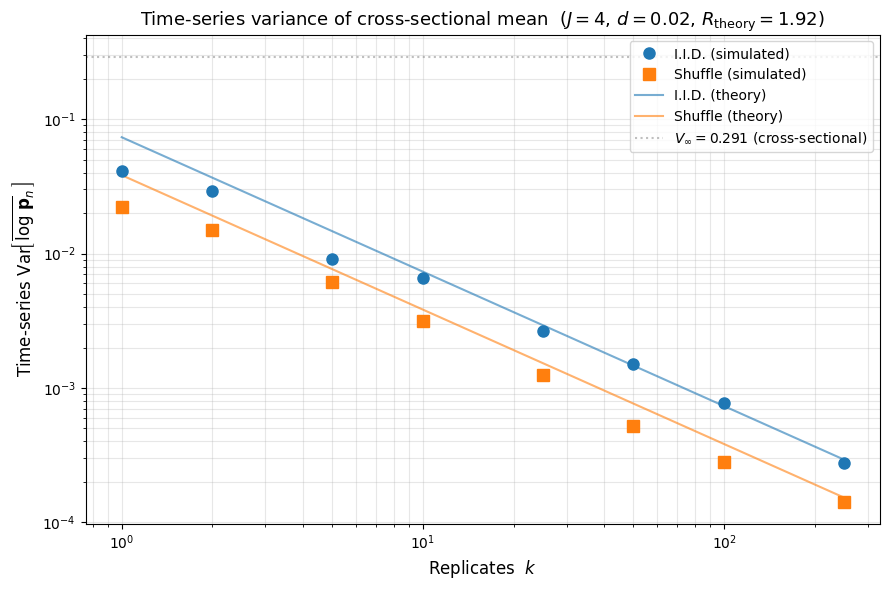

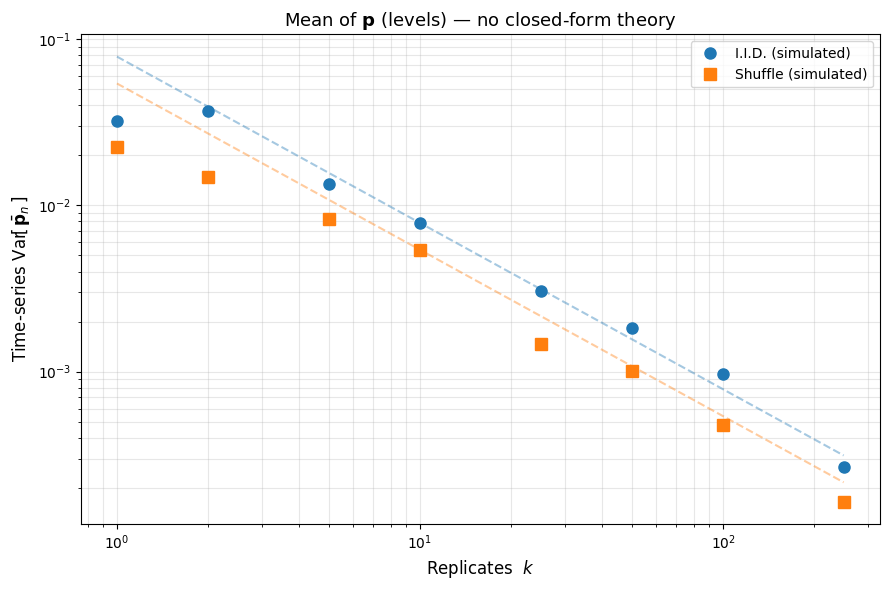

In [6]:
# --- Main figure: time-series variance of mean(log pLvl) vs replicates ---
# with theoretical predictions overlaid

reps = np.array(replicates)
k_fine = np.logspace(0, np.log10(reps[-1]), 200)
N_fine = k_fine * J

fig, ax = plt.subplots(figsize=(9, 6))

# Simulated
ax.loglog(
    reps,
    ts_var_log_iid,
    "o",
    color="C0",
    markersize=8,
    zorder=5,
    label="I.I.D. (simulated)",
)
ax.loglog(
    reps,
    ts_var_log_shf,
    "s",
    color="C1",
    markersize=8,
    zorder=5,
    label="Shuffle (simulated)",
)

# Theory
ax.loglog(
    k_fine,
    theory_ts_var_iid(N_fine),
    "-",
    color="C0",
    alpha=0.6,
    label="I.I.D. (theory)",
)
ax.loglog(
    k_fine,
    theory_ts_var_shf(N_fine),
    "-",
    color="C1",
    alpha=0.6,
    label="Shuffle (theory)",
)

# Ergodic cross-sectional variance as reference
ax.axhline(
    V_erg,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"$V_\\infty = {V_erg:.3f}$ (cross-sectional)",
)

ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(
    r"Time-series Var$\!\left[\,\overline{\log\,\mathbf{p}}_n\,\right]$", fontsize=12
)
ax.set_title(
    f"Time-series variance of cross-sectional mean  "
    f"($J={J}$, $d={death_prob}$, $R_{{\\mathrm{{theory}}}}={R_theory:.2f}$)",
    fontsize=13,
)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# --- Same for levels ---
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(
    reps, ts_var_lvl_iid, "o", color="C0", markersize=8, label="I.I.D. (simulated)"
)
ax.loglog(
    reps, ts_var_lvl_shf, "s", color="C1", markersize=8, label="Shuffle (simulated)"
)
# No clean theory for levels, just 1/k reference lines
ref_iid = ts_var_lvl_iid[3] * reps[3] / reps
ref_shf = ts_var_lvl_shf[3] * reps[3] / reps
ax.loglog(reps, ref_iid, "--", color="C0", alpha=0.4)
ax.loglog(reps, ref_shf, "--", color="C1", alpha=0.4)
ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(r"Time-series Var$\!\left[\,\bar{\mathbf{p}}_n\,\right]$", fontsize=12)
ax.set_title(r"Mean of $\mathbf{p}$ (levels) — no closed-form theory", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

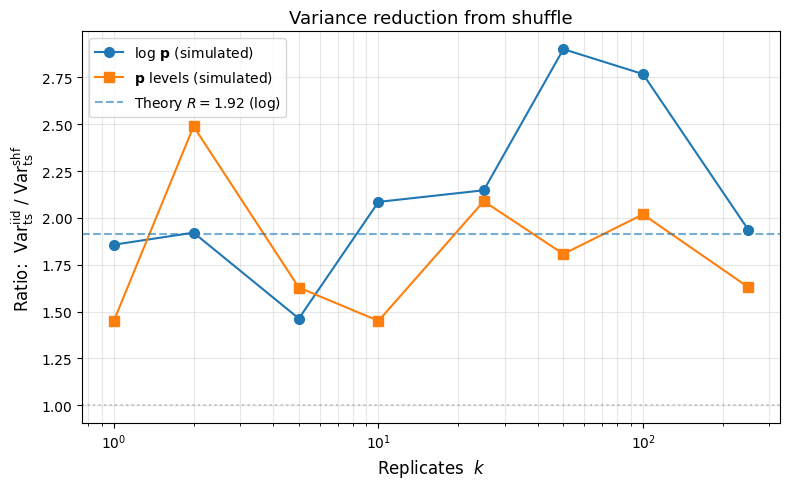

In [7]:
# --- Ratio plot with theoretical prediction ---
ratio_log = ts_var_log_iid / ts_var_log_shf
ratio_lvl = ts_var_lvl_iid / ts_var_lvl_shf

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(
    reps, ratio_log, "o-", label=r"$\log\,\mathbf{p}$ (simulated)", markersize=7
)
ax.semilogx(
    reps, ratio_lvl, "s-", label=r"$\mathbf{p}$ levels (simulated)", markersize=7
)
ax.axhline(
    R_theory,
    color="C0",
    linestyle="--",
    alpha=0.6,
    label=f"Theory $R = {R_theory:.2f}$ (log)",
)
ax.axhline(1, color="gray", linestyle=":", alpha=0.4)
ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(
    r"Ratio:  Var$_{\mathrm{ts}}^{\mathrm{iid}}$ / Var$_{\mathrm{ts}}^{\mathrm{shf}}$",
    fontsize=12,
)
ax.set_title("Variance reduction from shuffle", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# Summary

The time-series variance of $\overline{\log\mathbf{p}}$ has two components, both scaling as $1/N$:

| Source | Variance contribution | Shuffle? |
|--------|----------------------|----------|
| Death noise | $\frac{(1-d)(V_\infty + E_\infty^2)}{N(2-d)}$ | Same |
| Shock noise | $\frac{\sigma^2}{Nd(2-d)}$ | **Eliminated** |

The variance-reduction ratio $R = 1 + \frac{\sigma^2}{d(1-d)(V_\infty + E_\infty^2)}$ is a **constant** independent of $N$.  For these parameters, $R \approx 1.9$: shuffle roughly halves the time-series variance, regardless of how many agents are simulated.

The log-log plot confirms that simulated points lie on the theoretical curves, validating the AR(1) approximation.  The $V_\infty$ reference line shows the scale of cross-sectional dispersion for context — the time-series variance of the *mean* is orders of magnitude smaller (by a factor of $\sim N$).

# Application: Markov employment model with shuffled income shocks

The simple permanent-income simulation above demonstrates the mechanics of shuffled draws.  Now we apply the same technique to a more realistic setting: a **Markov employment model** inspired by [HAFiscal](https://github.com/econ-ark/HAFiscal), stripped of aggregate shocks and fiscal experiments.

## Model overview

Agents transition between **7 discrete employment states**:

| State | Label | Income (as fraction of $\mathbf{p}$) |
|:-----:|-------|--------------------------------------|
| 0 | Employed | Lognormal permanent ($\psi$) and transitory ($\theta$) shocks |
| 1 | Unemployed, UI quarter 1 | Deterministic: $\psi=1$, $\theta=0.7$ |
| 2 | Unemployed, UI quarter 2 | Deterministic: $\psi=1$, $\theta=0.7$ |
| 3 | Unemployed, no benefits, quarter 3 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 4 | Unemployed, no benefits, quarter 4 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 5 | Unemployed, no benefits, quarter 5 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 6 | Unemployed, no benefits, quarter 6 | Deterministic: $\psi=1$, $\theta=0.5$ → **forced reemployment** |

Unemployment spells are capped at 6 quarters: state 6 transitions to employment with probability 1.  This ensures a finite state space with rational steady-state probabilities, so `income_shuffle` can achieve exact frequency matching within each state.

### Transition matrix

Parameterized by:
- Steady-state unemployment rate $u = 0.05$ (quarterly)
- Average unemployment duration $\bar{U} = 1.5$ quarters
- UI benefit duration: 2 quarters (states 1–2)

The reemployment probability from any unemployed state is $1 - U_{\text{persist}} = 1/\bar{U} \approx 0.667$, except state 6 which forces reemployment.

### Key question

With `income_shuffle=True`, the employed agents' income shocks ($\psi, \theta$) are drawn with exact frequency matching.  The Markov transitions themselves remain stochastic.  Does eliminating the shock-noise component measurably reduce the time-series variance of aggregate consumption?

In [8]:
from HARK.ConsumptionSaving.ConsMarkovModel import MarkovConsumerType
from HARK.distributions import (
    DiscreteDistribution,
    DiscreteDistributionLabeled,
    combine_indep_dstns,
    MeanOneLogNormal,
)

# --- Markov transition matrix (7 states) ---
K = 7
Urate = 0.05  # quarterly unemployment rate
Uspell = 1.5  # average unemployment duration (quarters)
U_persist = 1 - 1 / Uspell  # prob of staying unemployed
E_persist = 1 - Urate * (1 - U_persist) / (1 - Urate)  # prob of staying employed

TM = np.zeros((K, K))
TM[0, 0] = E_persist
TM[0, 1] = 1 - E_persist  # employed → unemployed (UI q1)
for s in range(1, 6):
    TM[s, 0] = 1 - U_persist  # reemployment
    TM[s, s + 1] = U_persist  # advance to next unemployment quarter
TM[6, 0] = 1.0  # forced reemployment after 6 quarters

print("Transition matrix (rows = from, cols = to):")
state_labels = ["E", "U1", "U2", "U3", "U4", "U5", "U6"]
header = "     " + "  ".join(f"{s:>6s}" for s in state_labels)
print(header)
for i, row in enumerate(TM):
    print(f"  {state_labels[i]:>2s}  " + "  ".join(f"{v:6.4f}" for v in row))

# Verify: steady-state distribution
eigvals, eigvecs = np.linalg.eig(TM.T)
ss_idx = np.argmin(np.abs(eigvals - 1.0))
ss_dist = np.real(eigvecs[:, ss_idx])
ss_dist = ss_dist / ss_dist.sum()
print("\nSteady-state distribution:")
for s, p in zip(state_labels, ss_dist):
    print(f"  {s}: {p:.4f}")
print(f"  Total unemployment: {ss_dist[1:].sum():.4f}")

Transition matrix (rows = from, cols = to):
          E      U1      U2      U3      U4      U5      U6
   E  0.9649  0.0351  0.0000  0.0000  0.0000  0.0000  0.0000
  U1  0.6667  0.0000  0.3333  0.0000  0.0000  0.0000  0.0000
  U2  0.6667  0.0000  0.0000  0.3333  0.0000  0.0000  0.0000
  U3  0.6667  0.0000  0.0000  0.0000  0.3333  0.0000  0.0000
  U4  0.6667  0.0000  0.0000  0.0000  0.0000  0.3333  0.0000
  U5  0.6667  0.0000  0.0000  0.0000  0.0000  0.0000  0.3333
  U6  1.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000

Steady-state distribution:
  E: 0.9501
  U1: 0.0333
  U2: 0.0111
  U3: 0.0037
  U4: 0.0012
  U5: 0.0004
  U6: 0.0001
  Total unemployment: 0.0499


In [9]:
# --- Income shock distributions by state ---

# Employed: lognormal permanent + transitory shocks (HAFiscal calibration)
PermShkDstn_emp = MeanOneLogNormal(np.sqrt(0.003)).discretize(7, method="equiprobable")
TranShkDstn_emp = MeanOneLogNormal(np.sqrt(0.12)).discretize(7, method="equiprobable")
emp_dstn_raw = combine_indep_dstns(PermShkDstn_emp, TranShkDstn_emp)
emp_dstn = DiscreteDistributionLabeled(
    pmv=emp_dstn_raw.pmv,
    atoms=emp_dstn_raw.atoms,
    var_names=["PermShk", "TranShk"],
)

# Unemployed with UI (states 1-2): deterministic PermShk=1, TranShk=0.7
ui_dstn = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.7]]),
    var_names=["PermShk", "TranShk"],
)

# Unemployed, no benefits (states 3-6): deterministic PermShk=1, TranShk=0.5
nob_dstn = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.5]]),
    var_names=["PermShk", "TranShk"],
)

# IncShkDstn: list of lists, [period][state]
IncShkDstn_markov = [
    [emp_dstn, ui_dstn, ui_dstn, nob_dstn, nob_dstn, nob_dstn, nob_dstn]
]

# Marginal distributions for the solver
PermShkDstn_unemp = DiscreteDistribution(np.ones(1), np.array([1.0]))
TranShkDstn_ui = DiscreteDistribution(np.ones(1), np.array([0.7]))
TranShkDstn_nob = DiscreteDistribution(np.ones(1), np.array([0.5]))

PermShkDstn_markov = [[PermShkDstn_emp] + [PermShkDstn_unemp] * 6]
TranShkDstn_markov = [[TranShkDstn_emp] + [TranShkDstn_ui] * 2 + [TranShkDstn_nob] * 4]

print(
    f"Employed income distribution: {emp_dstn.atoms.shape[1]} joint atoms (7×7 perm×tran)"
)
print(f"  E[PermShk] = {emp_dstn.atoms[0] @ emp_dstn.pmv:.4f}")
print(f"  E[TranShk] = {emp_dstn.atoms[1] @ emp_dstn.pmv:.4f}")
print(f"Unemployed (UI):  TranShk = {ui_dstn.atoms[1, 0]:.1f}")
print(f"Unemployed (NoB): TranShk = {nob_dstn.atoms[1, 0]:.1f}")

Employed income distribution: 49 joint atoms (7×7 perm×tran)
  E[PermShk] = 1.0000
  E[TranShk] = 1.0000
Unemployed (UI):  TranShk = 0.7
Unemployed (NoB): TranShk = 0.5


In [10]:
# --- Build and solve the Markov consumer ---

# Initial Markov distribution: everyone starts employed
MrkvPrbsInit = np.zeros(K)
MrkvPrbsInit[0] = 1.0
MrkvInitDstn = DiscreteDistribution(MrkvPrbsInit, np.arange(K))

# Common parameters (HAFiscal HS-graduate calibration, quarterly)
common_params = dict(
    cycles=0,
    T_cycle=1,
    construct=False,  # we supply IncShkDstn, MrkvArray, etc. directly
    CRRA=2.0,
    DiscFac=0.966,
    Rfree=[np.full(K, 1.01)],
    LivPrb=[np.full(K, 0.99375)],
    PermGroFac=[np.array([1.00453] + [1.0] * 6)],  # growth only when employed
    BoroCnstArt=0.0,
    MrkvArray=[TM],
    IncShkDstn=IncShkDstn_markov,
    PermShkDstn=PermShkDstn_markov,
    TranShkDstn=TranShkDstn_markov,
    MrkvPrbsInit=MrkvPrbsInit,
    MrkvInitDstn=MrkvInitDstn,
    aXtraMin=0.001,
    aXtraMax=40,
    aXtraCount=48,
    aXtraNestFac=3,
    aXtraExtra=None,
    kLogInitMean=-12.0,
    kLogInitStd=0.0,
    kNrmInitCount=15,
    pLogInitMean=0.0,
    pLogInitStd=0.0,
    pLvlInitCount=15,
)


def make_markov_agent(
    income_shuffle=False,
    markov_shuffle=False,
    death_shuffle=False,
    N=1400,
    T_sim=400,
    seed=0,
):
    """Create, solve, and simulate a Markov consumer with given shuffle settings.

    Parameters
    ----------
    income_shuffle : bool
        Use shuffled draws for income shocks (PermShk, TranShk).
    markov_shuffle : bool
        Use shuffled draws for Markov state transitions.
    death_shuffle : bool
        Use deterministic death counts with random agent assignment.
    """
    agent = MarkovConsumerType(
        **common_params,
        income_shuffle=income_shuffle,
        markov_shuffle=markov_shuffle,
        death_shuffle=death_shuffle,
        AgentCount=N,
        T_sim=T_sim,
        seed=seed,
    )
    agent.construct("aXtraGrid", "solution_terminal", "kNrmInitDstn", "pLvlInitDstn")
    agent.solve()
    agent.track_vars = ["cNrm", "pLvl", "aNrm"]
    agent.initialize_sim()
    agent.simulate()
    return agent


# Quick test: solve once
test_agent = make_markov_agent(
    income_shuffle=False, markov_shuffle=False, N=700, T_sim=10
)
print("Model solved and simulated successfully.")
print(f"  AgentCount = {test_agent.AgentCount}")
print(
    f"  Markov state counts: {dict(zip(state_labels, np.bincount(test_agent.shocks['Mrkv'].astype(int), minlength=K)))}"
)
print(f"  Mean cNrm = {np.mean(test_agent.controls['cNrm']):.4f}")

Model solved and simulated successfully.
  AgentCount = 700
  Markov state counts: {'E': np.int64(671), 'U1': np.int64(17), 'U2': np.int64(7), 'U3': np.int64(3), 'U4': np.int64(2), 'U5': np.int64(0), 'U6': np.int64(0)}
  Mean cNrm = 0.9727


`# Compare time-series variance of aggregate consumption across shuffle configurations`

We have two effective shuffle controls for variance reduction:
- `income_shuffle`: eliminates sampling noise in income shocks (PermShk, TranShk)
- `death_shuffle`: eliminates binomial noise in death counts (exactly the right number die each period)

<!-- NOTE: `markov_shuffle` (deterministic transition *counts*) is also available but
commented out here.  It helps for linear aggregates like mean(cNrm) but does NOT
reduce variance of convex aggregates like marginal utility, because MU depends on
*which* agents transition (their wealth), not just *how many*.  Controlling
agent-level composition would require deterministic distribution propagation
(Young 2010), which is a fundamentally different approach. -->

We compare key combinations to see how much each technique reduces the time-series variance of aggregate statistics.  Three aggregates are tracked:
- `mean(cNrm)`: mean normalized consumption (linear, well-behaved)
- `mean(MU)`: mean marginal utility $(p \cdot c^{\rm nrm})^{-\rho}$ (convex, tail-sensitive)
- `mean(cLvl)`: mean consumption in levels (level-dependent)

In [11]:
# --- Compare time-series variance across configurations and population sizes ---
# Track three aggregates: mean(cNrm), mean(cLvl), and mean marginal utility
# Marginal utility = (pLvl * cNrm)^{-CRRA} is highly sensitive to unemployed agents
# who have low consumption levels.

CRRA = 2.0  # must match common_params

# --- Control variable: how many population sizes to test ---
# Base population N=350.  Replicates multiply this: 1x, 4x, 16x → N=350, 1400, 5600.
# Set n_test_sizes to control how many to run (1 = just 350, 2 = 350+1400, 3 = all three).
n_test_sizes = 1  # <-- change this to 2 or 3 to run more sizes

base_N = 350
replicate_factors = [1, 4, 16][:n_test_sizes]
N_agents_list = [base_N * k for k in replicate_factors]

T_sim = 400
burn = 100
n_seeds = 8

# NOTE: markov_shuffle is omitted from this comparison.  It pins transition
# *counts* (how many agents switch states) but not transition *composition*
# (which agents switch).  For linear aggregates like mean(cNrm) it helps
# modestly (~10% at this calibration), but for convex aggregates like
# marginal utility — which depend on the wealth of transitioning agents —
# it provides no benefit.  See discussion cell below.
configs = {
    "Baseline": dict(income_shuffle=False, markov_shuffle=False, death_shuffle=False),
    "Income only": dict(income_shuffle=True, markov_shuffle=False, death_shuffle=False),
    "Death only": dict(income_shuffle=False, markov_shuffle=False, death_shuffle=True),
    "Income + Death": dict(
        income_shuffle=True, markov_shuffle=False, death_shuffle=True
    ),
}

agg_names = ["mean(cNrm)", "mean(MU)", "mean(cLvl)"]

# Results indexed by (N, config, aggregate); also track wall-clock time
all_ts_var = {}
all_times = {}

for N in N_agents_list:
    ts_var_N = {name: {agg: 0.0 for agg in agg_names} for name in configs}
    times_N = {}

    for name, kwargs in configs.items():
        var_accum = {agg: [] for agg in agg_names}
        t0 = time.perf_counter()
        for s in range(n_seeds):
            agent = make_markov_agent(**kwargs, N=N, T_sim=T_sim, seed=s)
            ts_cNrm = np.array(
                [np.mean(agent.history["cNrm"][t]) for t in range(T_sim)]
            )
            ts_cLvl = np.array(
                [
                    np.mean(agent.history["cNrm"][t] * agent.history["pLvl"][t])
                    for t in range(T_sim)
                ]
            )
            ts_MU = np.array(
                [
                    np.mean(
                        (agent.history["pLvl"][t] * agent.history["cNrm"][t]) ** (-CRRA)
                    )
                    for t in range(T_sim)
                ]
            )
            var_accum["mean(cNrm)"].append(np.var(ts_cNrm[burn:]))
            var_accum["mean(MU)"].append(np.var(ts_MU[burn:]))
            var_accum["mean(cLvl)"].append(np.var(ts_cLvl[burn:]))
        times_N[name] = time.perf_counter() - t0

        for agg in agg_names:
            ts_var_N[name][agg] = np.mean(var_accum[agg])

    all_ts_var[N] = ts_var_N
    all_times[N] = times_N

    # Print results for this N
    base = ts_var_N["Baseline"]
    k = N // base_N
    print(f"\n{'=' * 75}")
    print(f"N = {N}  (replicates = {k})")
    print(f"{'=' * 75}")
    print(f"{'Config':>15s}", end="")
    for agg in agg_names:
        print(f"  {agg:>14s}", end="")
    print(f"  {'time (s)':>10s}  {'slowdown':>8s}")
    print("-" * 85)
    base_time = times_N["Baseline"]
    for cname in configs:
        print(f"{cname:>15s}", end="")
        for agg in agg_names:
            v = ts_var_N[cname][agg]
            print(f"  {v:>14.3e}", end="")
        t = times_N[cname]
        slowdown = t / base_time if base_time > 0 else float("inf")
        print(f"  {t:>10.1f}  {slowdown:>7.2f}x")

    print("\nVariance reduction ratio (baseline / config):")
    for cname in list(configs)[1:]:
        print(f"  {cname:>15s}", end="")
        for agg in agg_names:
            ratio = (
                base[agg] / ts_var_N[cname][agg]
                if ts_var_N[cname][agg] > 0
                else float("inf")
            )
            print(f"  {ratio:>13.1f}x", end="")
        print()


N = 350  (replicates = 1)
         Config      mean(cNrm)        mean(MU)      mean(cLvl)    time (s)  slowdown
-------------------------------------------------------------------------------------
       Baseline       3.772e-05       3.799e-03       3.980e-02        12.6     1.00x
    Income only       1.046e-05       3.238e-03       4.402e-02        13.7     1.09x
     Death only       3.590e-05       4.958e-03       6.044e-02        11.9     0.94x
 Income + Death       1.022e-05       6.729e-03       5.458e-02        12.8     1.02x

Variance reduction ratio (baseline / config):
      Income only            3.6x            1.2x            0.9x
       Death only            1.1x            0.8x            0.7x
   Income + Death            3.7x            0.6x            0.7x


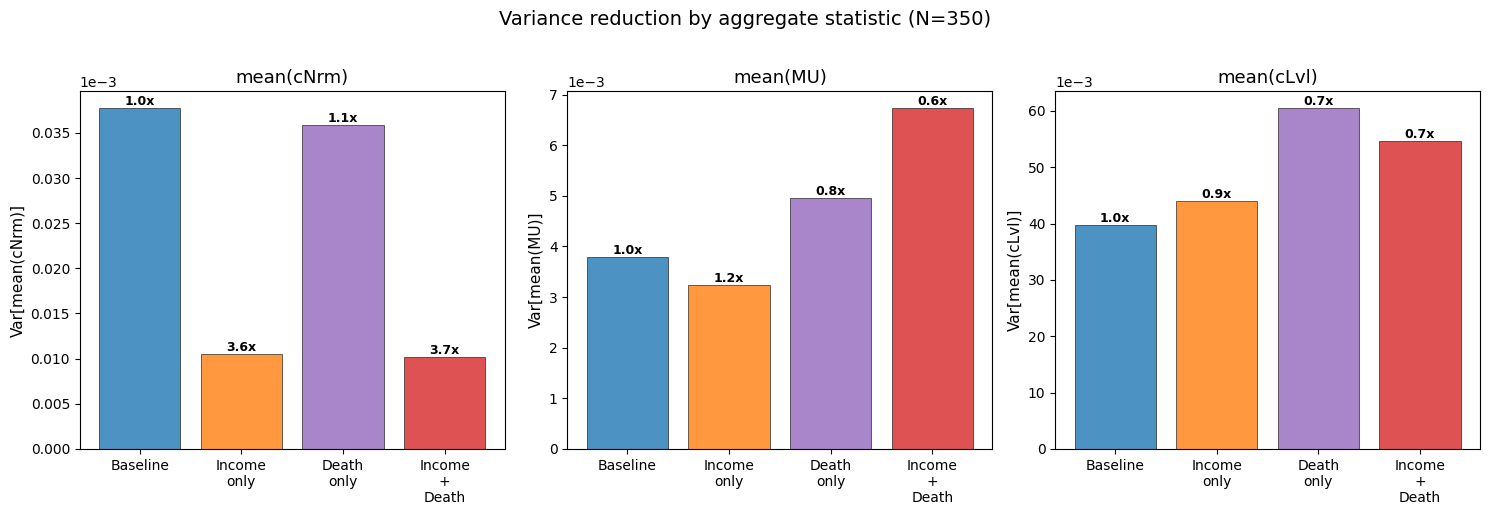

In [12]:
# --- Bar chart: variance reduction ratio by aggregate and config (smallest N) ---

colors = {
    "Baseline": "C0",
    "Income only": "C1",
    "Death only": "C4",
    "Income + Death": "C3",
}
N_plot = N_agents_list[0]
ts_var_plot = all_ts_var[N_plot]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, agg in zip(axes, agg_names):
    names = list(configs.keys())
    vals = [ts_var_plot[n][agg] for n in names]
    base_val = ts_var_plot["Baseline"][agg]
    bar_colors = [colors[n] for n in names]

    bars = ax.bar(
        [n.replace(" ", "\n") for n in names],
        vals,
        color=bar_colors,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )
    for bar, v in zip(bars, vals):
        ratio = base_val / v if v > 0 else float("inf")
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{ratio:.1f}x",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )
    ax.set_ylabel(f"Var[{agg}]", fontsize=11)
    ax.set_title(agg, fontsize=13)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(-3, -3))

fig.suptitle(
    f"Variance reduction by aggregate statistic (N={N_plot})",
    fontsize=14,
    y=1.02,
)
fig.tight_layout()
plt.show()

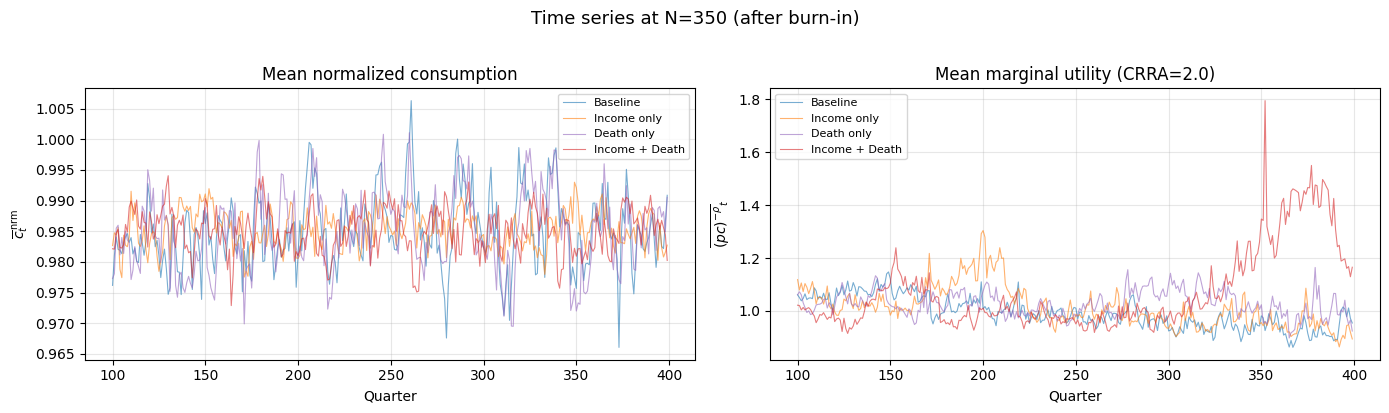

In [13]:
# --- Time-series plot: mean(cNrm) and mean(MU) side by side ---

N_demo_mrkv = N_agents_list[0]
T_demo_mrkv = T_sim

agents = {}
for name, kwargs in configs.items():
    agents[name] = make_markov_agent(
        **kwargs, N=N_demo_mrkv, T_sim=T_demo_mrkv, seed=42
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
quarters = np.arange(T_demo_mrkv)

# Left: mean(cNrm)
ax = axes[0]
for name in configs:
    mean_c = np.array(
        [np.mean(agents[name].history["cNrm"][t]) for t in range(T_demo_mrkv)]
    )
    ax.plot(
        quarters[burn:],
        mean_c[burn:],
        alpha=0.6,
        linewidth=0.8,
        color=colors[name],
        label=name,
    )
ax.set_xlabel("Quarter")
ax.set_ylabel(r"$\overline{c}^{\,\mathrm{nrm}}_t$")
ax.set_title("Mean normalized consumption", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: mean(MU)
ax = axes[1]
for name in configs:
    mean_mu = np.array(
        [
            np.mean(
                (agents[name].history["pLvl"][t] * agents[name].history["cNrm"][t])
                ** (-CRRA)
            )
            for t in range(T_demo_mrkv)
        ]
    )
    ax.plot(
        quarters[burn:],
        mean_mu[burn:],
        alpha=0.6,
        linewidth=0.8,
        color=colors[name],
        label=name,
    )
ax.set_xlabel("Quarter")
ax.set_ylabel(r"$\overline{(pc)^{-\rho}}_t$")
ax.set_title(f"Mean marginal utility (CRRA={CRRA})", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle(f"Time series at N={N_demo_mrkv} (after burn-in)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## Discussion

In this Markov employment model, there are multiple sources of simulation noise in aggregate statistics:

1. **Income shock noise** (employed agents' PermShk, TranShk): reduced by `income_shuffle=True`
2. **Death/rebirth noise** (how many agents die and get replaced): reduced by `death_shuffle=True`
3. **Markov transition composition** (which specific agents become unemployed): NOT addressed by any shuffle technique

Each shuffle technique targets a different noise source:

- **Income shuffle** uses the floor-plus-leftover algorithm to match exact shock frequencies.
- **Death shuffle** fixes `round(N * DiePrb)` deaths per period with random agent assignment, eliminating the binomial noise in death counts.  (This follows the pattern already used unconditionally in `AggShockConsumerType`.)

### Why `markov_shuffle` is not included

HARK also provides `markov_shuffle=True`, which pins the exact *count* of agents transitioning between states each period.  However, our experiments show it has limited value:

- For **linear aggregates** like `mean(cNrm)`, it helps modestly (~10% variance reduction at this calibration) because `mean(cNrm)` is driven primarily by *how many* agents are unemployed.
- For **convex aggregates** like marginal utility $(pc)^{-\rho}$, it provides **no benefit** because MU depends on *which* agents transition (their wealth level), not just how many.  Our diagnostic confirmed this: the correlation between the unemployed count and mean(MU) is only 0.25.

We also implemented and tested `balanced_transitions`, which uses systematic sampling on pLvl to make the transitioning group representative of the source population.  This too provided negligible MU improvement, for a fundamental reason: systematic sampling in rank space gives one agent per decile of the population, but the convexity of MU means the bottom decile (lowest pLvl) dominates, and which *specific* agent from that decile transitions still has high variance.

**The deeper issue:** reducing variance of convex aggregates in Markov models requires controlling the *joint distribution* of who transitions, not just the counts or even the marginal composition.  This points toward deterministic distribution propagation methods (Young 2010) rather than agent-level shuffle techniques.

# Permanent income normalization: a complementary technique

The shuffle techniques above eliminate sampling noise from **shocks** (income and Markov transitions).  But there is another source of cross-sectional noise: the **distribution of permanent income** $\mathbf{p}$ itself drifts away from its analytical moments due to accumulated shock noise and death/rebirth randomness.

`PermanentIncomeNormalizationMixin` (in `HARK.simulation.normalization`) addresses this by rescaling $\log(\mathbf{p})$ within each age cohort after every period so that the cross-sectional mean and standard deviation match their analytical values.  The affine transform in log-space preserves rank ordering of agents' permanent incomes.

This is implemented as a **mixin class** — it doesn't modify `IndShockConsumerType` or `MarkovConsumerType` at all.  You compose it via multiple inheritance:

```python
from HARK.simulation.normalization import PermanentIncomeNormalizationMixin
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType

class NormalizedIndShock(PermanentIncomeNormalizationMixin, IndShockConsumerType):
    pass

agent = NormalizedIndShock(normalize_pLvl=True, ...)
```

In [14]:
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType
from HARK.simulation.normalization import PermanentIncomeNormalizationMixin


class NormalizedIndShock(PermanentIncomeNormalizationMixin, IndShockConsumerType):
    pass


# Compare with and without normalization
N_norm = 2000
T_norm = 200

agent_plain = IndShockConsumerType(AgentCount=N_norm, T_sim=T_norm)
agent_plain.solve()
agent_plain.initialize_sim()
agent_plain.simulate()

agent_normd = NormalizedIndShock(AgentCount=N_norm, T_sim=T_norm, normalize_pLvl=True)
agent_normd.solve()
agent_normd.initialize_sim()
agent_normd.simulate()

# Check per-cohort log(pLvl) moments at a few ages
print("Per-cohort log(pLvl) moments at selected ages:")
print(
    f"{'Age':>4s}  {'Analytical mu':>14s}  {'Plain mu':>14s}  {'Normalized mu':>14s}  {'Plain err':>10s}  {'Normd err':>10s}"
)
for k in [5, 10, 20, 40]:
    mask_p = agent_plain.t_age == k
    mask_n = agent_normd.t_age == k
    if mask_p.sum() < 10 or mask_n.sum() < 10:
        continue
    mu_k, sigma_k = agent_normd._analytical_log_pLvl_moments(k)
    mu_plain = np.mean(np.log(agent_plain.state_now["pLvl"][mask_p]))
    mu_normd = np.mean(np.log(agent_normd.state_now["pLvl"][mask_n]))
    print(
        f"{k:>4d}  {mu_k:>14.6f}  {mu_plain:>14.6f}  {mu_normd:>14.6f}"
        f"  {abs(mu_plain - mu_k):>10.2e}  {abs(mu_normd - mu_k):>10.2e}"
    )

Per-cohort log(pLvl) moments at selected ages:
 Age   Analytical mu        Plain mu   Normalized mu   Plain err   Normd err
   5        0.031061        0.022878        0.031061    8.18e-03    1.04e-17
  10        0.057448       -0.042875        0.057448    1.00e-01    1.39e-17
  20        0.110224        0.066731        0.110224    4.35e-02    4.16e-17
  40        0.215776        0.258372        0.215776    4.26e-02    0.00e+00


In [15]:
# --- Effect on time-series variance of mean(pLvl) ---
# With normalization, the cross-sectional distribution of pLvl is pinned to
# analytical moments each period, so the time-series variance of mean(pLvl)
# should be dramatically reduced.

T_pnorm = 300
burn_pnorm = 50
n_seeds_pnorm = 5

var_plain_ts = []
var_normd_ts = []
var_shfnm_ts = []  # shuffle + normalize combined
time_plain, time_normd, time_shfnm = 0, 0, 0

for s in range(n_seeds_pnorm):
    # Plain
    t0 = time.perf_counter()
    a = IndShockConsumerType(AgentCount=2000, T_sim=T_pnorm, seed=s)
    a.solve()
    a.initialize_sim()
    a.simulate()
    time_plain += time.perf_counter() - t0
    mean_p = [np.mean(a.history["pLvl"][t]) for t in range(T_pnorm)]
    var_plain_ts.append(np.var(mean_p[burn_pnorm:]))

    # Normalized only
    t0 = time.perf_counter()
    a = NormalizedIndShock(AgentCount=2000, T_sim=T_pnorm, normalize_pLvl=True, seed=s)
    a.solve()
    a.initialize_sim()
    a.simulate()
    time_normd += time.perf_counter() - t0
    mean_p = [np.mean(a.history["pLvl"][t]) for t in range(T_pnorm)]
    var_normd_ts.append(np.var(mean_p[burn_pnorm:]))

    # Shuffle + normalized
    t0 = time.perf_counter()
    a = NormalizedIndShock(
        AgentCount=2000,
        T_sim=T_pnorm,
        normalize_pLvl=True,
        income_shuffle=True,
        seed=s,
    )
    a.solve()
    a.initialize_sim()
    a.simulate()
    time_shfnm += time.perf_counter() - t0
    mean_p = [np.mean(a.history["pLvl"][t]) for t in range(T_pnorm)]
    var_shfnm_ts.append(np.var(mean_p[burn_pnorm:]))

print("Time-series variance of mean(pLvl):")
print(f"  Plain:                {np.mean(var_plain_ts):.4e}  ({time_plain:.1f}s)")
print(
    f"  Normalized:           {np.mean(var_normd_ts):.4e}  ({time_normd:.1f}s, {time_normd / time_plain:.2f}x)  "
    f"({np.mean(var_plain_ts) / np.mean(var_normd_ts):.1f}x variance reduction)"
)
print(
    f"  Shuffle + Normalized: {np.mean(var_shfnm_ts):.4e}  ({time_shfnm:.1f}s, {time_shfnm / time_plain:.2f}x)  "
    f"({np.mean(var_plain_ts) / np.mean(var_shfnm_ts):.1f}x variance reduction)"
)

Time-series variance of mean(pLvl):
  Plain:                2.3068e-02  (1.1s)
  Normalized:           1.8617e-02  (5.2s, 4.63x)  (1.2x variance reduction)
  Shuffle + Normalized: 1.5108e-02  (6.1s, 5.42x)  (1.5x variance reduction)


# How large is each technique's contribution?

The three variance-reduction techniques target different noise sources.  To understand their relative importance, we run a single comprehensive comparison on the `IndShockConsumerType` model (where all three apply) and decompose the total variance reduction.

In [16]:
# --- Comprehensive comparison: all technique combinations on IndShockConsumerType ---

N_comp = 2000
T_comp = 400
burn_comp = 100
n_seeds_comp = 8

indshk_configs = {
    "Baseline": dict(
        income_shuffle=False,
        death_shuffle=False,
        normalize_pLvl=False,
        cls=IndShockConsumerType,
    ),
    "Income shuffle": dict(
        income_shuffle=True,
        death_shuffle=False,
        normalize_pLvl=False,
        cls=IndShockConsumerType,
    ),
    "Death shuffle": dict(
        income_shuffle=False,
        death_shuffle=True,
        normalize_pLvl=False,
        cls=IndShockConsumerType,
    ),
    "pLvl normalization": dict(
        income_shuffle=False,
        death_shuffle=False,
        normalize_pLvl=True,
        cls=NormalizedIndShock,
    ),
    "All three": dict(
        income_shuffle=True,
        death_shuffle=True,
        normalize_pLvl=True,
        cls=NormalizedIndShock,
    ),
}

# Track variance of three different aggregates, plus wall-clock time
results = {}
indshk_times = {}
for name, cfg in indshk_configs.items():
    cls = cfg["cls"]
    var_mean_cNrm = []
    var_mean_logp = []
    var_mean_clvl = []

    t0 = time.perf_counter()
    for s in range(n_seeds_comp):
        kwargs = dict(AgentCount=N_comp, T_sim=T_comp, seed=s)
        if cfg["income_shuffle"]:
            kwargs["income_shuffle"] = True
        if cfg["death_shuffle"]:
            kwargs["death_shuffle"] = True
        if cfg["normalize_pLvl"]:
            kwargs["normalize_pLvl"] = True

        a = cls(**kwargs)
        a.solve()
        a.initialize_sim()
        a.simulate()

        ts_cNrm = np.array([np.mean(a.history["cNrm"][t]) for t in range(T_comp)])
        ts_logp = np.array(
            [np.mean(np.log(a.history["pLvl"][t])) for t in range(T_comp)]
        )
        ts_clvl = np.array(
            [
                np.mean(a.history["cNrm"][t] * a.history["pLvl"][t])
                for t in range(T_comp)
            ]
        )

        var_mean_cNrm.append(np.var(ts_cNrm[burn_comp:]))
        var_mean_logp.append(np.var(ts_logp[burn_comp:]))
        var_mean_clvl.append(np.var(ts_clvl[burn_comp:]))
    indshk_times[name] = time.perf_counter() - t0

    results[name] = {
        "cNrm": np.mean(var_mean_cNrm),
        "log_p": np.mean(var_mean_logp),
        "cLvl": np.mean(var_mean_clvl),
    }

# Print results table
aggregates = [("cNrm", "mean(cNrm)"), ("log_p", "mean(log p)"), ("cLvl", "mean(c*p)")]
baseline = results["Baseline"]
base_time_indshk = indshk_times["Baseline"]

print(
    f"Time-series variance of aggregate statistics (N={N_comp}, T={T_comp}, burn={burn_comp})"
)
print(f"{'':>25s}", end="")
for _, label in aggregates:
    print(f"  {label:>14s}", end="")
print(f"  {'time (s)':>10s}  {'slowdown':>8s}")
print("-" * 95)

for name in indshk_configs:
    print(f"{name:>25s}", end="")
    for key, _ in aggregates:
        v = results[name][key]
        print(f"  {v:>14.3e}", end="")
    t = indshk_times[name]
    slowdown = t / base_time_indshk if base_time_indshk > 0 else float("inf")
    print(f"  {t:>10.1f}  {slowdown:>7.2f}x")

print()
print("Variance reduction ratio (baseline / technique):")
print(f"{'':>25s}", end="")
for _, label in aggregates:
    print(f"  {label:>14s}", end="")
print()
print("-" * 73)
for name in list(indshk_configs)[1:]:
    print(f"{name:>25s}", end="")
    for key, _ in aggregates:
        ratio = (
            baseline[key] / results[name][key]
            if results[name][key] > 0
            else float("inf")
        )
        print(f"  {ratio:>13.1f}x", end="")
    print()

Time-series variance of aggregate statistics (N=2000, T=400, burn=100)
                               mean(cNrm)     mean(log p)       mean(c*p)    time (s)  slowdown
-----------------------------------------------------------------------------------------------
                 Baseline       1.055e-05       2.123e-04       8.797e-03         2.5     1.00x
           Income shuffle       4.532e-07       1.586e-04       1.027e-02         4.4     1.74x
            Death shuffle       1.061e-05       2.103e-04       1.287e-02         1.5     0.59x
       pLvl normalization       1.055e-05       1.013e-04       7.111e-03        11.7     4.68x
                All three       4.038e-07       1.096e-04       1.277e-02        12.5     4.97x

Variance reduction ratio (baseline / technique):
                               mean(cNrm)     mean(log p)       mean(c*p)
-------------------------------------------------------------------------
           Income shuffle           23.3x            1.3x  

In [17]:
# --- Variance decomposition for the Markov employment model ---
# Reuse results from the main comparison cell above.

N_decomp = N_agents_list[0]
ts_var_decomp = all_ts_var[N_decomp]

# Build per-aggregate result dicts for the decomposition
mrkv_results_cNrm = {name: ts_var_decomp[name]["mean(cNrm)"] for name in configs}
mrkv_results_MU = {name: ts_var_decomp[name]["mean(MU)"] for name in configs}

for label, results in [
    ("mean(cNrm)", mrkv_results_cNrm),
    ("mean(MU)", mrkv_results_MU),
]:
    V_total = results["Baseline"]
    print(f"\n{'=' * 65}")
    print(f"Aggregate: {label}  (N={N_decomp})")
    print(f"{'=' * 65}")
    for name in configs:
        v = results[name]
        ratio = V_total / v if v > 0 else float("inf")
        print(f"  {name:>15s}:  {v:.3e}  ({ratio:.1f}x reduction)")

    V_income = V_total - results["Income only"]
    V_death = V_total - results["Death only"]
    V_residual = results["Income + Death"]

    print("\n  Variance decomposition:")
    print(f"    Total:                {V_total:.3e}  (100%)")
    print(
        f"    Income shocks:        {V_income:.3e}  ({100 * V_income / V_total:.0f}%)"
    )
    print(f"    Death count noise:    {V_death:.3e}  ({100 * V_death / V_total:.0f}%)")
    print(
        f"    Residual:             {V_residual:.3e}  ({100 * V_residual / V_total:.0f}%)"
    )


Aggregate: mean(cNrm)  (N=350)
         Baseline:  3.772e-05  (1.0x reduction)
      Income only:  1.046e-05  (3.6x reduction)
       Death only:  3.590e-05  (1.1x reduction)
   Income + Death:  1.022e-05  (3.7x reduction)

  Variance decomposition:
    Total:                3.772e-05  (100%)
    Income shocks:        2.726e-05  (72%)
    Death count noise:    1.822e-06  (5%)
    Residual:             1.022e-05  (27%)

Aggregate: mean(MU)  (N=350)
         Baseline:  3.799e-03  (1.0x reduction)
      Income only:  3.238e-03  (1.2x reduction)
       Death only:  4.958e-03  (0.8x reduction)
   Income + Death:  6.729e-03  (0.6x reduction)

  Variance decomposition:
    Total:                3.799e-03  (100%)
    Income shocks:        5.619e-04  (15%)
    Death count noise:    -1.159e-03  (-31%)
    Residual:             6.729e-03  (177%)


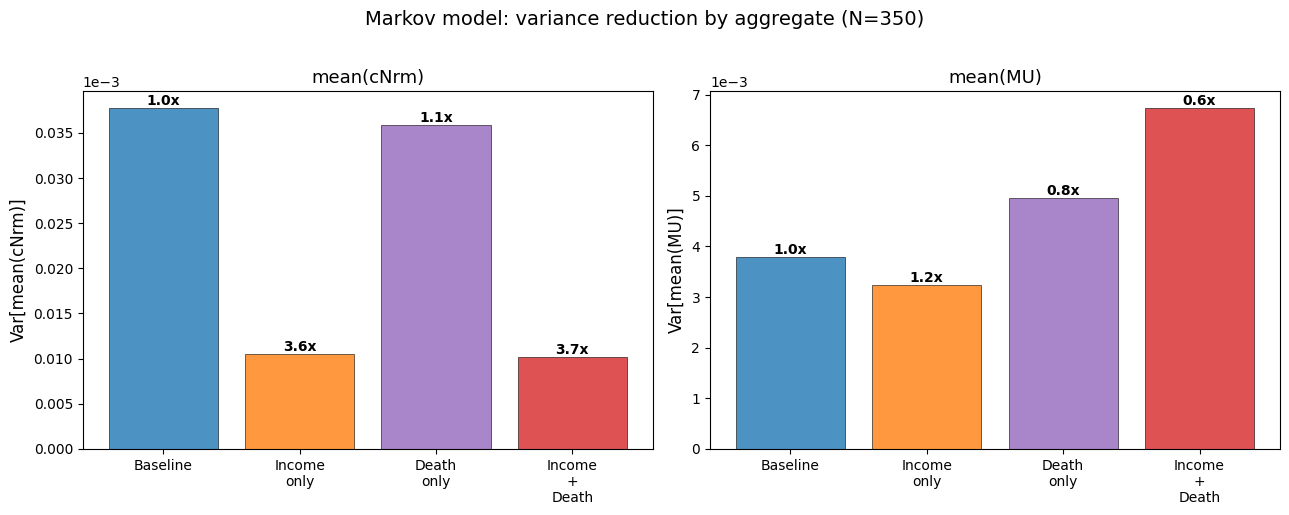

In [18]:
# --- Bar chart: decomposition for cNrm vs MU ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors_list = [colors[n] for n in configs]

for ax, (label, results) in zip(
    axes, [("mean(cNrm)", mrkv_results_cNrm), ("mean(MU)", mrkv_results_MU)]
):
    names = list(configs.keys())
    vals = [results[n] for n in names]
    base_val = results["Baseline"]

    bars = ax.bar(
        [n.replace(" ", "\n") for n in names],
        vals,
        color=bar_colors_list,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )
    for bar, v in zip(bars, vals):
        ratio = base_val / v if v > 0 else float("inf")
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{ratio:.1f}x",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )
    ax.set_ylabel(f"Var[{label}]", fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(-3, -3))

fig.suptitle(
    f"Markov model: variance reduction by aggregate (N={N_decomp})",
    fontsize=14,
    y=1.02,
)
fig.tight_layout()
plt.show()

## Interpretation

**Which technique matters most depends on the model and the aggregate statistic.**

### IndShockConsumerType (no Markov states)

There are two stochastic noise sources: **income shocks** and **death/rebirth counts**.

- **Income shuffle** is the dominant technique for `mean(cNrm)`.  It eliminates the shock-noise component of the time-series variance, which the AR(1) theory (above) predicts accounts for a fraction $\sigma^2 / [d(1-d)(V_\infty + E_\infty^2) + \sigma^2]$ of the total.
- **Death shuffle** eliminates binomial noise in how many agents die each period.  With `LivPrb = 0.99` and `N = 2000`, the standard deviation of death counts is $\sqrt{N \cdot d \cdot (1-d)} \approx 4.5$ agents per period.  Fixing this to a deterministic count removes one source of aggregate fluctuation.
- **pLvl normalization** provides a gain for level-dependent aggregates (`mean(log p)`, `mean(c*p)`) by preventing the permanent income distribution from drifting away from its analytical shape.
- **Combined**, the techniques are complementary: income shuffle eliminates per-period shock noise, death shuffle eliminates death-count noise, and normalization prevents cumulative drift.

### MarkovConsumerType (7-state employment model)

There are three conceptual noise sources: **income shocks**, **Markov transition counts**, and **Markov transition composition** (which agents transition).

- **Income shuffle** is the largest single contributor for `mean(cNrm)`, because employed agents (95% of the population) draw from a 49-atom joint distribution each period.
- **Death shuffle** eliminates the binomial noise in death counts, which is a modest but nonzero contribution.
- **Markov transition noise** is harder to address.  `markov_shuffle` can pin the *count* of transitions (helpful for linear aggregates like `mean(cNrm)`) but cannot control *which* agents transition.  For convex aggregates like marginal utility, the variance is dominated by the wealth composition of transitioning agents, which no agent-level shuffle technique can efficiently control.

### Limits of the shuffle approach for convex statistics

The key finding from this notebook is that **shuffle techniques are most effective for linear or mildly nonlinear aggregates**.  For highly convex aggregates like marginal utility $(pc)^{-\rho}$:

- Income shuffle still helps substantially (it controls what *shocks* agents receive, which is the largest noise source).
- But Markov-related noise is fundamentally about *which agents* are in which state, and this depends on the full joint distribution of $(p, a, \text{state})$.  Controlling this requires moving beyond agent-level shuffles toward **deterministic distribution propagation** (Young 2010), where the cross-sectional distribution is evolved as an object rather than simulated agent by agent.

### Practical recommendation

For most HARK simulations, **`income_shuffle=True` is the single most impactful change** and has zero computational cost.  Add `death_shuffle=True` to eliminate death-count noise.  Use `PermanentIncomeNormalizationMixin` when you need accurate level-dependent aggregates or are running very long simulations where cumulative pLvl drift matters.

For convex aggregates in Markov models, the remaining variance after income+death shuffles reflects a fundamental limitation of agent-based simulation with finite populations.  Reducing it further requires either much larger populations or non-stochastic simulation methods.